# __Modelado predictivo del desempeño de empleados__

Construye y evalua modelos predictivos para estimar el desempeño de los empleados. Se buscar predecir la variable KPIs_met_more_than_80 (si un empleado cumple más del 80% de sus KPIs) a partir de variables como región, educación, género, entrenamientos recibidos, edad, calificación del año anterior, antigüedad, premios ganados y puntaje promedio de entrenamiento.

Se usan como modelos la _Regresión Logística_ ya que es una tarea de clasificación binaria y el _Modelo de Apilamiento_ ya que combina las fortalezas de un arbol de decisión y una SVM.

## Librerías

In [1]:
# librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve

# modelo de apilamiento
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score

In [2]:
# Estilo de graficas
sns.set_theme(style="whitegrid")

## Carga de datos limpios

In [3]:
# Cargamos el dataset ya limpio, generado en 01_limpieza_datos.ipynb
data = pd.read_csv('employees_cleaned.csv')
data

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,f,other,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,m,other,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,f,other,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,m,sourcing,1,36,3.0,2,0,0,68
...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Sales & Marketing,31,Bachelors,m,other,1,42,3.0,10,0,0,53
15412,Sales & Marketing,25,Bachelors,m,sourcing,2,28,2.0,5,0,0,45
15413,Technology,7,Bachelors,f,referred,2,30,5.0,6,1,0,81
15414,HR,7,Bachelors,m,other,1,33,1.0,9,0,0,51


## Procesamiento de la data


### Copia de los datos

In [4]:
# Creamos una copia de los datos
df = data.copy()
df

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,f,other,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,m,other,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,f,other,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,m,sourcing,1,36,3.0,2,0,0,68
...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Sales & Marketing,31,Bachelors,m,other,1,42,3.0,10,0,0,53
15412,Sales & Marketing,25,Bachelors,m,sourcing,2,28,2.0,5,0,0,45
15413,Technology,7,Bachelors,f,referred,2,30,5.0,6,1,0,81
15414,HR,7,Bachelors,m,other,1,33,1.0,9,0,0,51


### Eliminar variables no relevantes

In [5]:
# Eliminamos variables de poco valor
df = df.drop(['department', 'recruitment_channel'], axis=1)
df

,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,4,Bachelors,f,1,31,3.0,5,0,0,51
1,13,Bachelors,m,1,31,1.0,4,0,0,47
2,2,Bachelors,f,3,31,2.0,9,0,0,65
3,29,Bachelors,m,1,30,4.0,7,0,0,61
4,7,Bachelors,m,1,36,3.0,2,0,0,68
...,...,...,...,...,...,...,...,...,...,...
15411,31,Bachelors,m,1,42,3.0,10,0,0,53
15412,25,Bachelors,m,2,28,2.0,5,0,0,45
15413,7,Bachelors,f,2,30,5.0,6,1,0,81
15414,7,Bachelors,m,1,33,1.0,9,0,0,51


### Convertir variables categóricas a numéricas

In [6]:
# Utilizamos esta transformada para variables Binaria
# creamos una clase LabelEncoder
le = LabelEncoder()

# pasamos la variable a convertir a la clase antes definida
df['gender'] = le.fit_transform(df['gender'])

# mostramos resultados
df.head()

,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,4,Bachelors,0,1,31,3.0,5,0,0,51
1,13,Bachelors,1,1,31,1.0,4,0,0,47
2,2,Bachelors,0,3,31,2.0,9,0,0,65
3,29,Bachelors,1,1,30,4.0,7,0,0,61
4,7,Bachelors,1,1,36,3.0,2,0,0,68


In [7]:
# Seleccion de variables predictoras
X = df.drop('KPIs_met_more_than_80', axis=1).values

# Seleccion de variable objetivo
y = df['KPIs_met_more_than_80'].values

X

array([[4, 'Bachelors', 0, ..., 5, 0, 51],
       [13, 'Bachelors', 1, ..., 4, 0, 47],
       [2, 'Bachelors', 0, ..., 9, 0, 65],
       ...,
       [7, 'Bachelors', 0, ..., 6, 0, 81],
       [7, 'Bachelors', 1, ..., 9, 0, 51],
       [7, 'Bachelors', 0, ..., 4, 0, 81]], shape=(15416, 9), dtype=object)

In [8]:
# Para variables categoricas de mas de dos valores utilizamos la transformacion OneHot
# Transformer
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')

# Aplicamos el Transformer sobre las variables predictoras
X = np.array(ct.fit_transform(X))

X

array([[1.0, 0.0, 0.0, ..., 5, 0, 51],
       [1.0, 0.0, 0.0, ..., 4, 0, 47],
       [1.0, 0.0, 0.0, ..., 9, 0, 65],
       ...,
       [1.0, 0.0, 0.0, ..., 6, 0, 81],
       [1.0, 0.0, 0.0, ..., 9, 0, 51],
       [1.0, 0.0, 0.0, ..., 4, 0, 81]], shape=(15416, 11), dtype=object)

### Selección de features relevantes

In [9]:
# Reconstruimos los nombres de las features en el mismo orden en que quedaron en X
# tras el OneHotEncoder (columnas de 'education') + las columnas restantes (remainder='passthrough')
onehot_feature_names = [f'education_{cat}' for cat in ct.named_transformers_['encoder'].categories_[0]]
remainder_feature_names = ['region', 'gender', 'no_of_trainings', 'age',
       'previous_year_rating', 'length_of_service', 'awards_won', 'avg_training_score']
feature_names = onehot_feature_names + remainder_feature_names

# creamos el objeto SelectKBest con f_regression scoring y k = 5
# k representa la catidad de variables que deseamos
selector = SelectKBest(score_func=f_regression, k=5)
# ajustamos el selector a los datos
selector.fit(X,y)

SelectKBest(k=5, score_func=<function f_regression at 0x7b7a5b983110>)

In [10]:
# Obtenemos la matriz de features transformada con solo las 5 features principales seleccionadas
X_selected = selector.transform(X)
X_selected

array([[1, 3.0, 5, 0, 51],
       [1, 1.0, 4, 0, 47],
       [3, 2.0, 9, 0, 65],
       ...,
       [2, 5.0, 6, 0, 81],
       [1, 1.0, 9, 0, 51],
       [1, 5.0, 4, 0, 81]], shape=(15416, 5), dtype=object)

In [11]:
# obtenemos el indice de los features seleccionados
selected_indices = selector.get_support(indices=True)
selected_indices

array([ 5,  7,  8,  9, 10])

In [12]:
# obtenemos los nombres de los features seleccionados de la lista de nombre de las variables originales
selected_features_names = [feature_names[idx] for idx in selected_indices]

# mostramos features
print('Top nombre de los features seleccionados:')
print(selected_features_names)

Top nombre de los features seleccionados:
['no_of_trainings', 'previous_year_rating', 'length_of_service', 'awards_won', 'avg_training_score']


### Dividir los datos en entrenamiento y de prueba

In [13]:
# dividimos los datos en dos grupos y guradamos en variables
# test_size: indica el tamano del grupo de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [14]:
X_train

array([[1.0, 0.0, 0.0, ..., 13, 0, 59],
       [1.0, 0.0, 0.0, ..., 2, 0, 58],
       [1.0, 0.0, 0.0, ..., 5, 0, 73],
       ...,
       [1.0, 0.0, 0.0, ..., 3, 0, 51],
       [1.0, 0.0, 0.0, ..., 5, 0, 63],
       [1.0, 0.0, 0.0, ..., 3, 0, 60]], shape=(12332, 11), dtype=object)

Los valores de entrenamiento no están normalizados. ¡Vamos a normalizarlo!

In [15]:
# Creamos el objeto Scalador
sc = StandardScaler()

# Normalizamos los valores de entrenamiento y de prueba
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

X_train

array([[ 0.69210675, -0.10869637, -0.67372278, ...,  1.62112741,
        -0.15736318, -0.32996384],
       [ 0.69210675, -0.10869637, -0.67372278, ..., -1.03112885,
        -0.15736318, -0.40496088],
       [ 0.69210675, -0.10869637, -0.67372278, ..., -0.30778623,
        -0.15736318,  0.71999464],
       ...,
       [ 0.69210675, -0.10869637, -0.67372278, ..., -0.79001464,
        -0.15736318, -0.92994012],
       [ 0.69210675, -0.10869637, -0.67372278, ..., -0.30778623,
        -0.15736318, -0.0299757 ],
       [ 0.69210675, -0.10869637, -0.67372278, ..., -0.79001464,
        -0.15736318, -0.25496681]], shape=(12332, 11))

## Modelo de clasificación

Vamos a utilizar el modelo de regresión logística.

In [16]:
# creamos un objeto con el modelo
classifier_lg = LogisticRegression(random_state=0)

# ajustamos el modelo a los datos de entrenamiento
classifier_lg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [17]:
# Creamos el predictor
y_pred = classifier_lg.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 1], shape=(3084,))

Calculamos algunas métricas descriptivas del modelo.

In [18]:
# Calculo de la exactitud
accuracy_lg = accuracy_score(y_test, y_pred)*100
# Calculo de la precision
precision_lg = precision_score(y_test, y_pred)*100
# Calculo puntaje del modelo
score_lg = f1_score(y_test,y_pred)*100
# Calculo recuperacion del modelo
recall_lg = recall_score(y_test,y_pred)*100

print('-------Metricas del modelo de Regresion Logistica----------')
print('Exactitud: ',accuracy_lg)
print('Precision: ',precision_lg)
print('Puntaje del modelo: ',score_lg)
print('Recuperacion: ',recall_lg)

-------Metricas del modelo de Regresion Logistica----------
Exactitud:  70.2983138780804
Precision:  60.731707317073166
Puntaje del modelo:  52.09205020920502
Recuperacion:  45.604395604395606


Creamos la matriz de confusión.

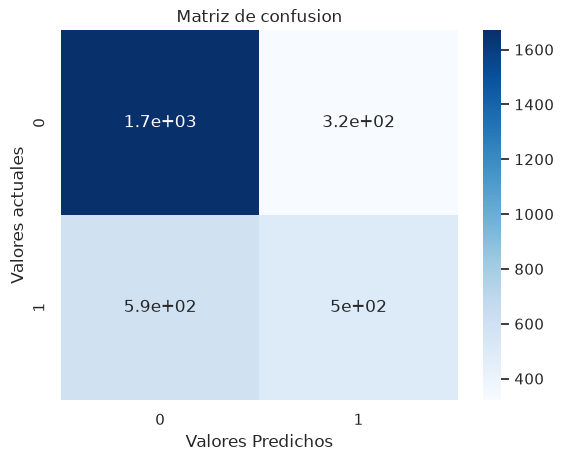

In [19]:
# Calculo de la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

# creamos el heatmap de la matriz de confusion
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Valores Predichos')
plt.ylabel('Valores actuales')
plt.title('Matriz de confusion');

## Curva de recuperación de la precisión del modelo

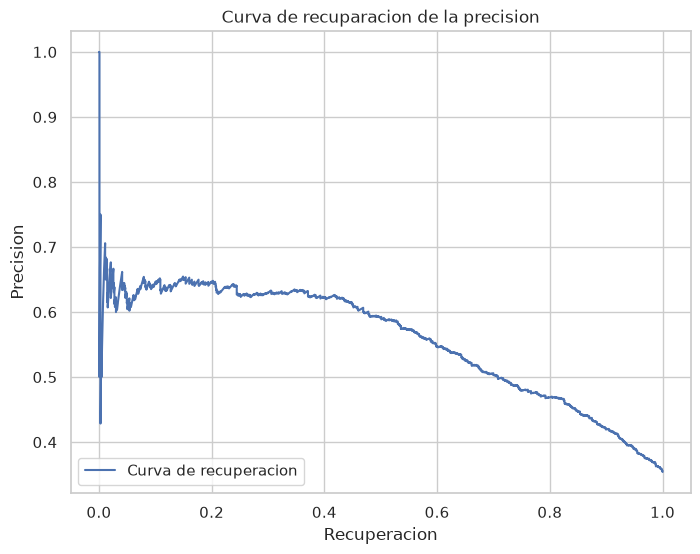

In [20]:
# tenemos el modelo lg y la data de prueba X_test, y_test
# obtenemos las estimaciones de probabilidad de la clase positiva
y_scores = classifier_lg.predict_proba(X_test)[:,1]

# obtenemos valores de los parametros
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Graficamos la curva
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Curva de recuperacion')
plt.xlabel('Recuperacion')
plt.ylabel('Precision')
plt.title('Curva de recuparacion de la precision')
plt.legend(loc='lower left');

## Modelo de apilamiento

In [21]:
# Estimadores base
base_learners = [
    ('rf_1', DecisionTreeClassifier()),
    ('rf_2', SVC())
]

# Meta modelo
logreg = LogisticRegression()

# Clasificador de apilamiento
stack_clf = StackingClassifier(estimators=base_learners, final_estimator=logreg)

# entrenamiento del modelo
stack_clf.fit(X_train, y_train)

# Crear la prediccion
y_pred_stack = stack_clf.predict(X_test)

In [22]:
# obtener los parametros del modelo
accuracy_stack = accuracy_score(y_test, y_pred_stack)*100
precision_stack = precision_score(y_test, y_pred_stack)*100
score_stack = f1_score(y_test, y_pred_stack)*100
recall_stack = recall_score(y_test, y_pred_stack)*100

print('-------Metricas del modelo de Apilamiento----------')
print('Exactitud: ',accuracy_stack)
print('Precision: ',precision_stack)
print('Puntaje del modelo: ',score_stack)
print('Recuperacion: ',recall_stack)

-------Metricas del modelo de Apilamiento----------
Exactitud:  70.75226977950713
Precision:  62.56613756613757
Puntaje del modelo:  51.19047619047619
Recuperacion:  43.315018315018314


## Curva operativa característica del receptor

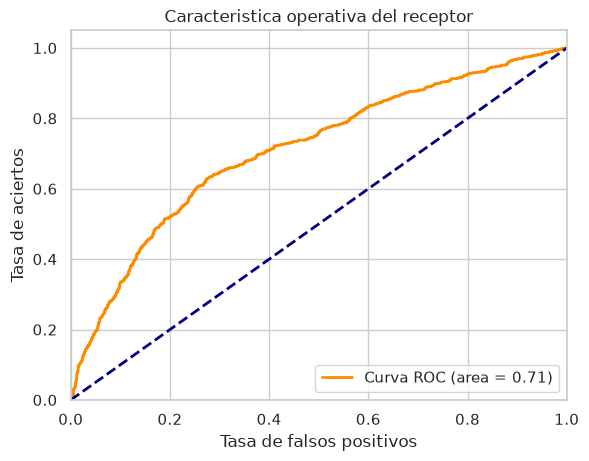

In [23]:
# ajustamos el modelos a los datos de entrenamiento
stack_clf.fit(X_train, y_train)

# predecimos las probabilidades de la clase positiva
y_prob = stack_clf.predict_proba(X_test)[:,1]

# Calculamos la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Graficamos la curva
plt.figure
lw=2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='Curva ROC (area = %0.2f)' %roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de aciertos')
plt.title('Caracteristica operativa del receptor')
plt.legend(loc="lower right");

## Validación cruzada de la regresión logística

In [24]:
# calculo de la validacion cruzada
accuracies = cross_val_score(estimator=classifier_lg, X=X_train, y=y_train, cv=10)

# mostrar valores
print('Precision: {:.2f} %'.format(accuracies.mean()*100))
print('Desviacion Estandar: {:.2f} %'.format(accuracies.std()*100))

Precision: 71.03 %
Desviacion Estandar: 1.29 %


## Evaluación de los modelos

In [25]:
# definimos los nombres de los modelos y sus respectivos valores de precision
model_names = ['Logistic Regression', 'Stack: Logistic Regression']
accuracy_values = [accuracy_lg, accuracy_stack]
precision_values = [precision_lg, precision_stack]
f1_score_values = [score_lg, score_stack]
recall_values = [recall_lg, recall_stack]

# creamos un diccionario con la data antes seleccionada
data = {'Model': model_names,
        'Accuracy': accuracy_values,
        'Precision': precision_values,
        'Recall': recall_values,
        'f1_score': f1_score_values}

# Creamos un dataframe con los datos
df = pd.DataFrame(data)

# mostrar resultados
df

,Model,Accuracy,Precision,Recall,f1_score
0,Logistic Regression,70.298314,60.731707,45.604396,52.092050
1,Stack: Logistic Regression,70.752270,62.566138,43.315018,51.190476


## Conclusiones

- La regresión logística obtiene una exactitud de 70.3% y el modelo de apilamiento 70.7%. Ninguno de los dos domina claramente al otro.

- El modelo de apilamiento mejora la precisión (62.5% vs. 60.7%) pero reduce el recall (43.3% vs. 45.6%) frente a la regresión logística. Esto indica que el modelo apilado es más conservador al predecir la clase positiva: comete menos falsos positivos, pero deja más falsos negativos sin detectar.

- Ambos modelos rondan el 52% de F1-score, confirmando que el modelo de apilamiento no aporta una mejora sustancial pese a su mayor complejidad y costo computacional.

- Cerca de la mitad de los empleados que efectivamente cumplen sus KPIs no está siendo identificada correctamente. Esto es relevante si el objetivo de negocio es detectar y reconocer al talento de alto desempeño.

- La validación cruzada de 10 folds sobre la regresión logística da una precisión promedio de 71.03% con una desviación estándar baja (1.29%), lo que sugiere que el modelo generaliza de forma consistente y no depende fuertemente de la partición de datos usada.

> Dado el desempeño similar entre ambos modelos, la regresión logística resulta preferible por su simplicidad, interpretabilidad y menor costo computacional.